In [108]:
import pandas as pd
from data_util import find_closest_elements
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pq_file = "/mnt/hd1/data/uw-options-cache/SPX/2025-12-19.parquet.gzip"
df = pd.read_parquet(pq_file)

In [47]:
df.columns

Index(['executed_at', 'underlying_symbol', 'option_chain_id', 'side', 'strike',
       'option_type', 'expiry', 'underlying_price', 'nbbo_bid', 'nbbo_ask',
       'ewma_nbbo_bid', 'ewma_nbbo_ask', 'price', 'size', 'premium', 'volume',
       'open_interest', 'implied_volatility', 'delta', 'theta', 'gamma',
       'vega', 'rho', 'theo', 'sector', 'exchange', 'report_flags', 'canceled',
       'upstream_condition_detail', 'equity_type', 'tstamp', 'tstamp_sec'],
      dtype='object')

In [135]:



print(df.shape)
# pd.MultiIndex.from_tuples(
cols = ['tstamp_sec','expiry','strike','option_type']
strikecounts = df[cols].groupby(['tstamp_sec','strike']).count()
expirycounts = df[cols].groupby(['tstamp_sec','expiry']).count()
fdf = df[df.apply(lambda x: 
                  expirycounts[pd.MultiIndex.from_tuples([x.tstamp_sec,x.expiry])] > 2 \
                  and strikecounts[pd.MultiIndex.from_tuples(x.tstamp_sec,x.strike)] > 10,axis=1)]
print(fdf.shape,'!!!!!!!!!!!!!1111')


(1000193, 32)


TypeError: Input must be a list / sequence of tuple-likes.

<Axes: xlabel='strike', ylabel='implied_volatility'>

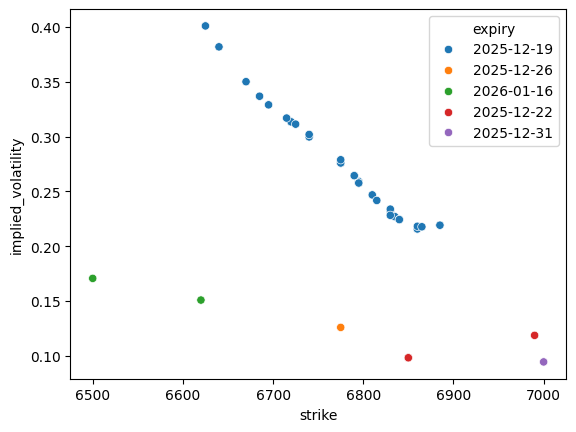

In [129]:
idx = counts.index[18]
tmpdf = df[df.tstamp_sec == idx]
sns.scatterplot(tmpdf,x='strike',y='implied_volatility',hue='expiry')

In [81]:
len(df.tstamp_sec.unique())

24964

In [74]:
counts.index[0]

np.int64(112)

In [31]:
len(df)

1000193

In [ ]:
df.columns

In [3]:
df.head(10)

,date,forward_price,tau,risk_free_rate,is_call,strike_price,option_price,log_moneyness,implied_volatility,delta,time_to_maturity
0,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1255.0,0.100,-0.151241,0.364894,-0.003813,9
1,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1260.0,0.100,-0.147264,0.356226,-0.003900,9
2,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1270.0,0.100,-0.139359,0.338941,-0.004084,9
3,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1275.0,0.125,-0.135430,0.338461,-0.005015,9
4,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1280.0,0.150,-0.131516,0.336568,-0.005953,9
5,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1285.0,0.200,-0.127618,0.339030,-0.007680,9
6,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1290.0,0.225,-0.123734,0.334715,-0.008646,9
7,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1295.0,0.200,-0.119866,0.320733,-0.008082,9
8,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1300.0,0.150,-0.116012,0.300980,-0.006601,9
9,2013-01-02,1459.912086,0.024658,0.001955,-1.0,1305.0,0.175,-0.112173,0.297554,-0.007673,9


In [4]:
target_ttms = [7, 30, 90]
target_deltas = [0.5, 0.25, -0.25]

In [5]:
df_tmp = df.groupby('date').apply(find_closest_elements, 'time_to_maturity', target_ttms, include_groups=False)

In [6]:
reference_options = df_tmp.groupby(['date','time_to_maturity']).apply(find_closest_elements, 'delta', target_deltas, include_groups=False)

In [7]:
df['is_ref'] = 0

In [8]:
df.loc[reference_options.index.get_level_values(-1), 'is_ref'] = 1

In [9]:
df.to_hdf(path_or_buf='spx_w_ref.h5', key='df', complevel=9, complib='blosc')